# 47 - CNN conf60 4-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "4class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_4class
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_4class_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionImageDataset(dataset_dir / f"X_{split}_images.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
    negative: 58


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8210     0.7360     0.7722    0.8273   0.3386   0.000100  (33.3s)


     2      0.4943     0.8646     0.7775    0.7737   0.2934   0.000100  (33.3s)


     3      0.4424     0.8627     0.6642    0.8031   0.3030   0.000100  (33.4s)


     4      0.4100     0.8676     0.6510    0.8135   0.2957   0.000100  (33.3s)


...

    30      0.1381     0.9474     0.9631    0.8100   0.3799   0.000050  (33.1s)


    31      0.1302     0.9546     0.9635    0.7807   0.3754   0.000050  (33.1s)


    32      0.1308     0.9561     0.8958    0.7962   0.3586   0.000050  (33.1s)


    33      0.1184     0.9607     0.9287    0.8066   0.3596   0.000050  (33.1s)


    34      0.1133     0.9629     1.0045    0.7686   0.3444   0.000050  (33.1s)

Early stopping at epoch 34. Best epoch: 19 (val_f1=0.4477)

Best: epoch 19, val_acc=0.8342, val_f1=0.4477
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/cnn_b1.pth


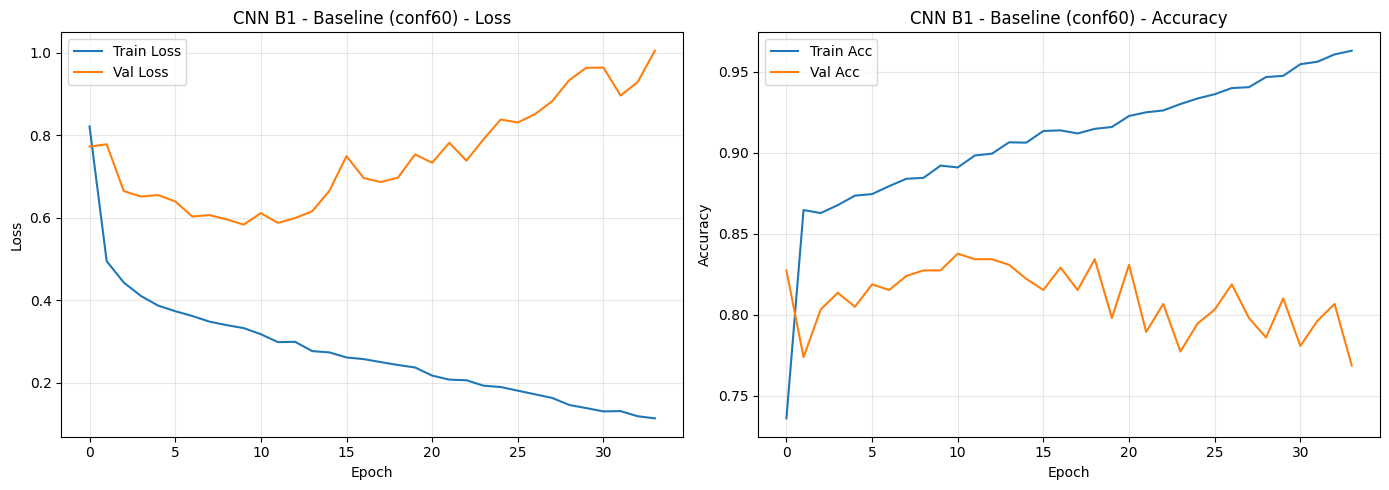

Test Loss: 0.5210
Test Accuracy: 0.8084
Test Macro F1: 0.4376
Test Weighted F1: 0.7980

Classification Report:
              precision    recall  f1-score   support

     neutral       0.89      0.87      0.88       688
       happy       0.61      0.80      0.69       183
         sad       0.33      0.12      0.18        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.81       929
   macro avg       0.46      0.45      0.44       929
weighted avg       0.80      0.81      0.80       929



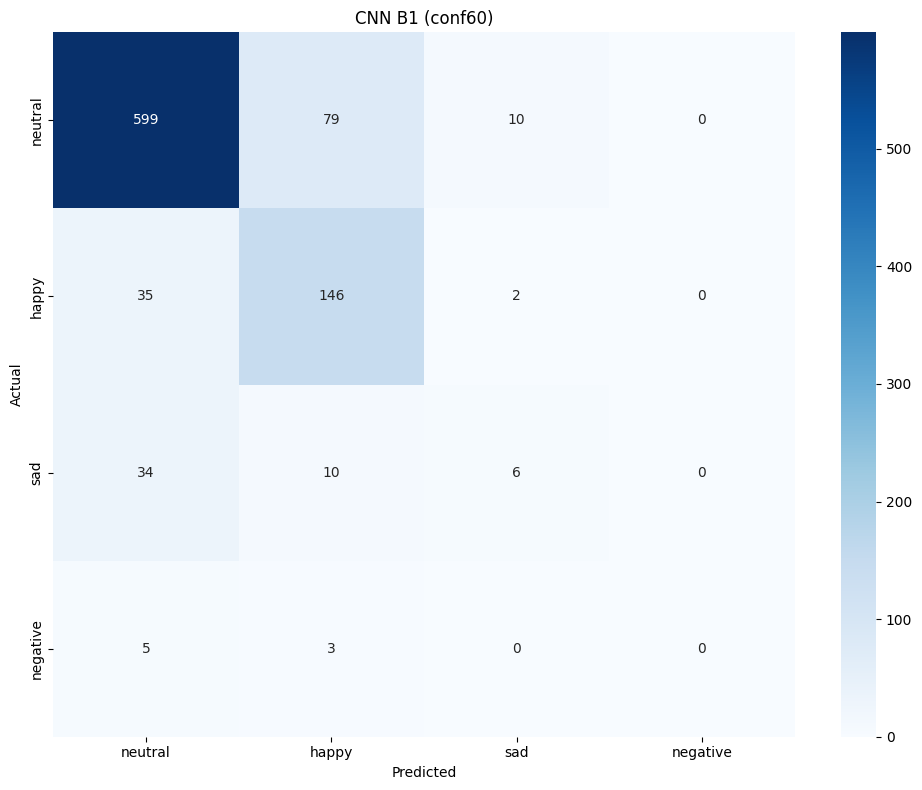

B1: Acc=0.8084 F1=0.4376

Class weights: None


Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9558     0.6595     0.9090    0.7340   0.2861   0.000100  (33.1s)


     2      0.5179     0.8610     0.7025    0.8100   0.2914   0.000100  (33.2s)


     3      0.4463     0.8642     0.6574    0.7927   0.2554   0.000100  (33.3s)


...

    23      0.1816     0.9374     0.7381    0.8238   0.3641   0.000050  (33.2s)


    24      0.1755     0.9366     0.7227    0.8152   0.3586   0.000050  (33.2s)


    25      0.1659     0.9406     0.7267    0.7651   0.3613   0.000050  (33.1s)


    26      0.1597     0.9419     0.7284    0.7824   0.3727   0.000050  (33.0s)


    27      0.1566     0.9429     0.7622    0.7945   0.3621   0.000050  (33.1s)

Early stopping at epoch 27. Best epoch: 12 (val_f1=0.4020)

Best: epoch 12, val_acc=0.8325, val_f1=0.4020
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/cnn_b2.pth


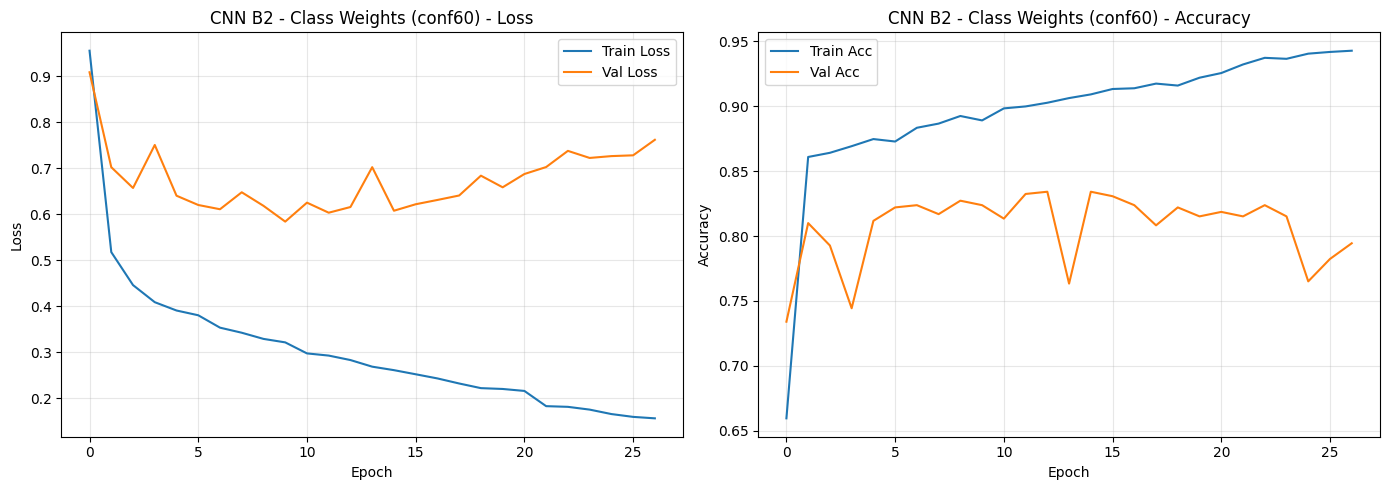

Test Loss: 0.5500
Test Accuracy: 0.8256
Test Macro F1: 0.4477
Test Weighted F1: 0.8146

Classification Report:
              precision    recall  f1-score   support

     neutral       0.90      0.90      0.90       688
       happy       0.65      0.75      0.70       183
         sad       0.30      0.14      0.19        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.83       929
   macro avg       0.46      0.45      0.45       929
weighted avg       0.81      0.83      0.81       929



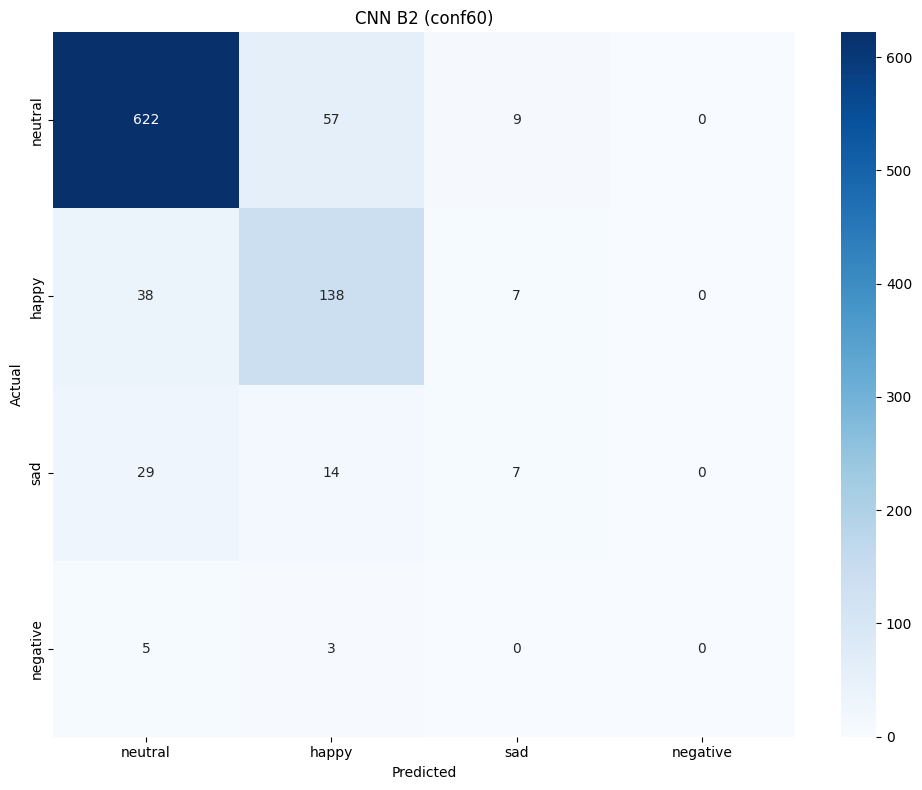

B2: Acc=0.8256 F1=0.4477


Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
    negative: 600



Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9528     0.6390     0.7143    0.8238   0.2259   0.000100  (36.9s)


     2      0.6063     0.7991     0.7085    0.8204   0.2614   0.000100  (37.3s)


...

    29      0.1137     0.9633     1.0418    0.7703   0.3194   0.000050  (37.4s)


    30      0.1043     0.9652     1.0802    0.7686   0.3305   0.000050  (37.3s)


    31      0.1005     0.9657     1.1953    0.6943   0.2968   0.000050  (37.2s)


    32      0.0912     0.9700     1.0450    0.7737   0.3247   0.000050  (37.2s)


    33      0.0931     0.9672     1.1597    0.7409   0.3158   0.000050  (37.2s)

Early stopping at epoch 33. Best epoch: 18 (val_f1=0.3749)

Best: epoch 18, val_acc=0.7893, val_f1=0.3749
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/cnn_b3.pth


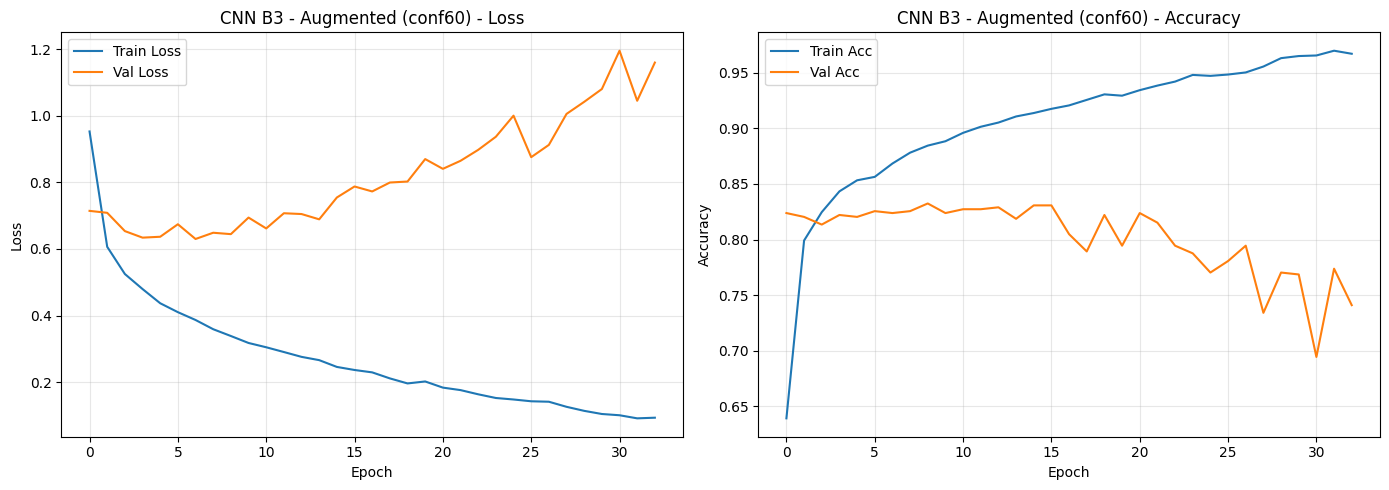

Test Loss: 0.6600
Test Accuracy: 0.7600
Test Macro F1: 0.4320
Test Weighted F1: 0.7620

Classification Report:
              precision    recall  f1-score   support

     neutral       0.84      0.86      0.85       688
       happy       0.64      0.56      0.60       183
         sad       0.48      0.20      0.28        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.76       929
   macro avg       0.49      0.41      0.43       929
weighted avg       0.77      0.76      0.76       929



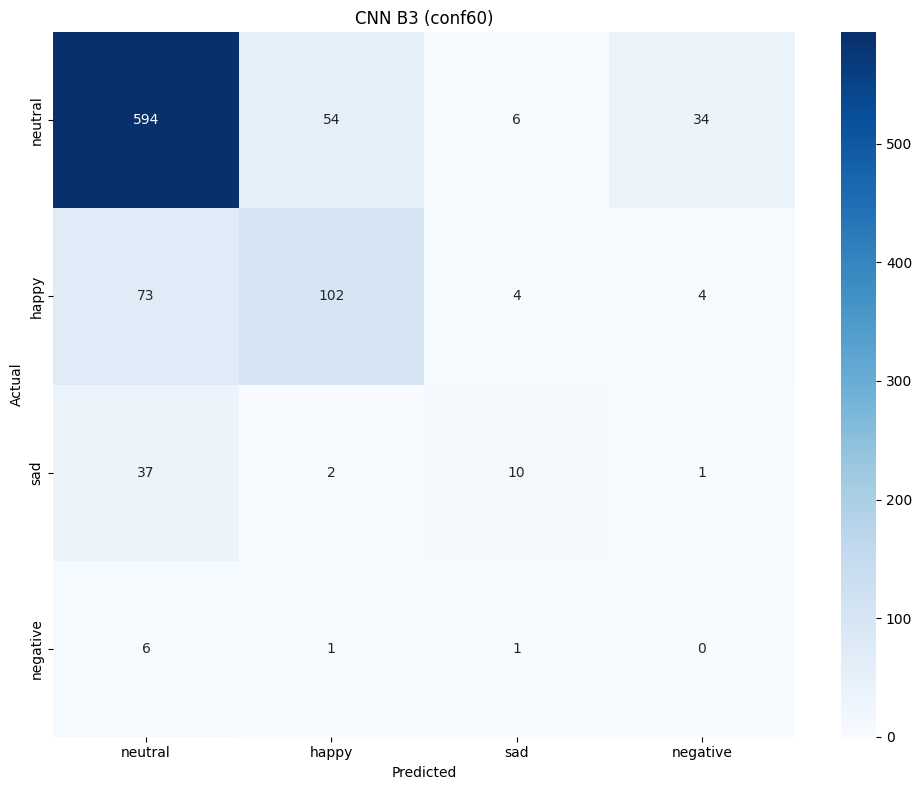

B3: Acc=0.7600 F1=0.4320

RINGKASAN CNN (conf60)
  B1 Baseline               Acc=0.8084 F1=0.4376
  B2 Class Weights          Acc=0.8256 F1=0.4477
  B3 Weights+Aug            Acc=0.7600 F1=0.4320

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/cnn_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_b1.pth"))
plot_training_history(history_b1, "CNN B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "CNN B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_b2.pth"))
plot_training_history(history_b2, "CNN B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "CNN B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_b3.pth"))
plot_training_history(history_b3, "CNN B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "CNN B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN CNN (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "cnn_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'cnn_results.json'}")